In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt

In [2]:
grid_size = 5

start = (0, 0)
goal = (4, 4)

obstacles = [(1,1), (2,2), (3,1)]

In [14]:
actions = ["up", "down", "left", "right"]
action_size = len(actions)

In [15]:
Q = np.zeros((grid_size, grid_size, action_size))

In [16]:
def step(state, action):
    x, y = state

    if action == "up":
        x = max(0, x-1)
    elif action == "down":
        x = min(grid_size-1, x+1)
    elif action == "left":
        y = max(0, y-1)
    elif action == "right":
        y = min(grid_size-1, y+1)

    new_state = (x, y)

    if new_state in obstacles:
        return state, -10, False

    if new_state == goal:
        return new_state, 100, True

    return new_state, -1, False

In [17]:
alpha = 0.1
gamma = 0.9
epsilon = 0.2
episodes = 1000

for episode in range(episodes):
    state = start
    done = False

    while not done:
        x, y = state

        # exploration vs exploitation
        if random.uniform(0,1) < epsilon:
            action_idx = random.randint(0, action_size-1)
        else:
            action_idx = np.argmax(Q[x, y])

        action = actions[action_idx]

        new_state, reward, done = step(state, action)
        nx, ny = new_state

        # Q update
        Q[x, y, action_idx] = Q[x, y, action_idx] + alpha * (
            reward + gamma * np.max(Q[nx, ny]) - Q[x, y, action_idx]
        )

        state = new_state

In [18]:
state = start
path = [state]

for _ in range(50):
    x, y = state
    action_idx = np.argmax(Q[x, y])
    action = actions[action_idx]

    state, _, done = step(state, action)
    path.append(state)

    if done:
        break

print("Final Path:", path)

Final Path: [(0, 0), (0, 1), (0, 2), (0, 3), (1, 3), (2, 3), (2, 4), (3, 4), (4, 4)]


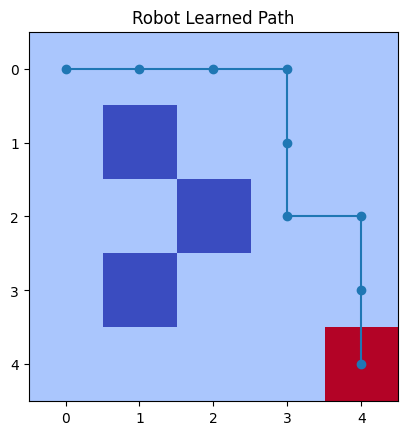

In [19]:
grid = np.zeros((grid_size, grid_size))

for ox, oy in obstacles:
    grid[ox][oy] = -1

gx, gy = goal
grid[gx][gy] = 2

px = [p[0] for p in path]
py = [p[1] for p in path]

plt.imshow(grid, cmap="coolwarm")
plt.plot(py, px, marker="o")
plt.title("Robot Learned Path")
plt.show()